# Classification — End-to-End ML Pipeline (Practical Implementation)

> Here the target is now a **category** instead of a continuous number.

---

## What's different from regression?

| Aspect | Regression | Classification |
|--------|-----------|----------------|
| Target type | Continuous number (e.g. price) | Discrete class (yes/no, 0/1, A/B/C) |
| Output | A number | A label + probability |
| Loss function | MSE / MAE | Log-loss / Cross-entropy |
| Metrics | RMSE, MAE, R² | Accuracy, Precision, Recall, F1, ROC-AUC |
| Diagnostics | Residual plots | Confusion matrix, ROC, PR curves |
| Imbalance issue | Rare | **Common** — most fraud cases are NOT fraud |

---

## Pipeline (same shape as regression)

```
Problem → Data → EDA → Clean → Feature Eng →
    Select → Split → Scale → Train → Evaluate →
        Tune → CV → Interpret → Deploy
```

The only steps that change: **metrics** (8) and **imbalance handling** (10).

---

## Table of Contents

| # | Section |
|---|---------|
| 0 | Classification overview |
| 1 | Setup — imports |
| 2 | EDA — Breast Cancer dataset |
| 3 | Preprocessing + train/test split |
| 4 | 8 classification algorithms |
| 5 | Classification metrics in depth |
| 6 | Confusion matrix + ROC + PR curves |
| 7 | Handling class imbalance |
| 8 | Cross-validation + hyperparameter tuning |
| 9 | **Project 1 — Customer Churn Prediction** |
| 10 | **Project 2 — Credit Risk Model** |
| 11 | **Project 3 — Fraud Detection (imbalanced)** |
| 12 | **Project 4 — Recommendation System** (content-based) |
| 13 | **Capstone — NLP Text Classification** |
| 14 | Summary |


---
# 0. Classification — Quick Overview

A classifier outputs **probabilities for each class**, then picks the class with the highest probability (default threshold = 0.5 for binary).

### Types of classification

| Type | Example |
|------|---------|
| Binary | spam / not-spam, churn / stay |
| Multi-class | digit recognition (0–9) |
| Multi-label | a photo tagged "beach + sunset + people" (multiple labels per row) |

### Algorithms we'll cover

| # | Algorithm | Type | Key idea |
|---|-----------|------|----------|
| 1 | Logistic Regression | Linear | Sigmoid maps `wx+b` to a probability |
| 2 | Naive Bayes | Probabilistic | Bayes' rule + feature independence assumption |
| 3 | KNN | Instance-based | Predict by majority vote of k nearest neighbors |
| 4 | Decision Tree | Tree | Recursive yes/no splits |
| 5 | Random Forest | Tree ensemble | Many trees vote |
| 6 | Gradient Boosting | Tree ensemble | Trees fix each other's errors sequentially |
| 7 | XGBoost | Tree ensemble | Boosted, regularized, fast |
| 8 | SVC (RBF) | Kernel method | Maximum-margin boundary, kernel for non-linearity |


---
# 1. Setup — Imports

Run this cell **first** — every later cell depends on these imports.


In [31]:
# ── 1. Imports & config ───────────────────────────────────────────────────
import warnings                                  # silence noisy warnings
warnings.filterwarnings('ignore')

import ssl                                       # macOS SSL fix for sklearn downloads
ssl._create_default_https_context = ssl._create_unverified_context

import numpy as np                               # arrays & math
import pandas as pd                              # DataFrames
import matplotlib.pyplot as plt                  # plotting
import seaborn as sns                            # nicer statistical plots

# ── Datasets ──────────────────────────────────────────────────────────────
from sklearn.datasets import (
    load_breast_cancer,                          # binary classification — 569 rows
    fetch_20newsgroups,                          # text classification — for NLP capstone
    make_classification                          # synthetic data generator
)

# ── Preprocessing ─────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ── Splitting & validation ────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, GridSearchCV, RandomizedSearchCV
)

# ── Classifiers ───────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes  import GaussianNB, MultinomialNB
from sklearn.neighbors    import KNeighborsClassifier
from sklearn.tree         import DecisionTreeClassifier
from sklearn.ensemble     import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm          import SVC
from xgboost              import XGBClassifier

# ── Metrics ───────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    log_loss
)

# ── NLP (used in capstone) ────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# reproducibility & plot defaults
np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('All libraries imported ✔')


All libraries imported ✔


### Code Explanation — Setup

| Import | Why |
|--------|-----|
| `load_breast_cancer` | Built-in binary dataset (malignant vs benign) — clean and small |
| `fetch_20newsgroups` | Text dataset for the NLP capstone |
| `make_classification` | Generate synthetic data for fraud/churn-style examples |
| `StratifiedKFold` | CV that **preserves class balance** in each fold — important for imbalance |
| `LogisticRegression` | Linear baseline classifier |
| `GaussianNB` | Naive Bayes for continuous features |
| `MultinomialNB` | Naive Bayes for word counts (NLP) |
| `XGBClassifier` | Usually the strongest tabular classifier |
| `confusion_matrix` etc | Classification-specific metrics |
| `TfidfVectorizer` | Converts text → numerical features |


---
# 2. EDA — Breast Cancer Dataset

A clean binary classification dataset:
- **569 rows × 30 numeric features** (cell nucleus measurements from biopsy images)
- **Target:** 0 = malignant, 1 = benign
- Classes are **moderately balanced** (~63% benign, ~37% malignant)


In [32]:
# ── 2a. Load the dataset ──────────────────────────────────────────────────
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')                       # 0 = malignant, 1 = benign

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')
print(f'Class names    : {data.target_names.tolist()}')         # ['malignant', 'benign']
print(f'Class counts   :\n{y.value_counts().to_string()}')
print(f'Class balance  : {(y.value_counts(normalize=True)*100).round(1).to_string()}')
X.head()


Features shape : (569, 30)
Target shape   : (569,)
Class names    : ['malignant', 'benign']
Class counts   :
1    357
0    212
Class balance  : 1    62.7
0    37.3


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Code Explanation
- `load_breast_cancer()` — returns a Bunch with `.data`, `.target`, `.feature_names`, `.target_names`.
- `value_counts(normalize=True)` — gives class proportions; check this **before** training.
- ~63/37 split — manageable, but in fraud or rare-disease problems you may see 99/1 — covered later.


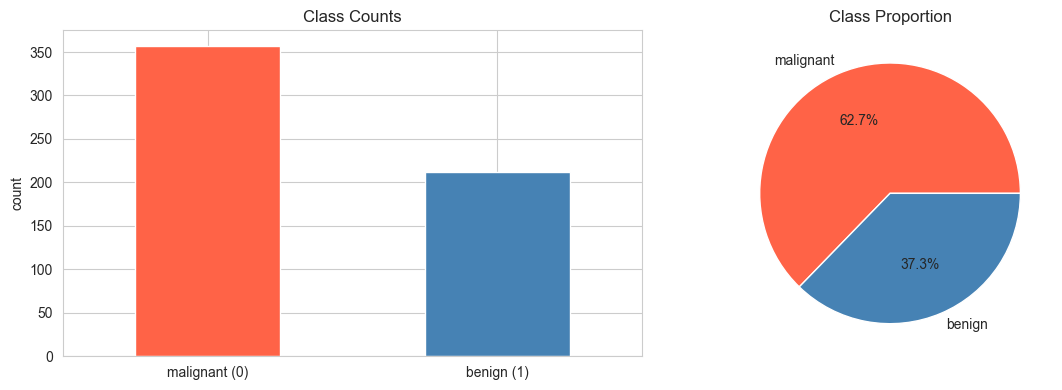

In [33]:
# ── 2b. Class balance plot ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# bar chart
y.value_counts().plot.bar(ax=axes[0], color=['tomato', 'steelblue'])
axes[0].set_xticklabels(['malignant (0)', 'benign (1)'], rotation=0)
axes[0].set_title('Class Counts')
axes[0].set_ylabel('count')

# pie
y.value_counts().plot.pie(ax=axes[1], labels=['malignant', 'benign'],
                          colors=['tomato','steelblue'], autopct='%1.1f%%')
axes[1].set_title('Class Proportion')
axes[1].set_ylabel('')
plt.tight_layout(); plt.show()


### Code Explanation
- Always inspect class balance first — it dictates which metric you'll trust later.
- Bar + pie shows raw counts and proportions side-by-side.


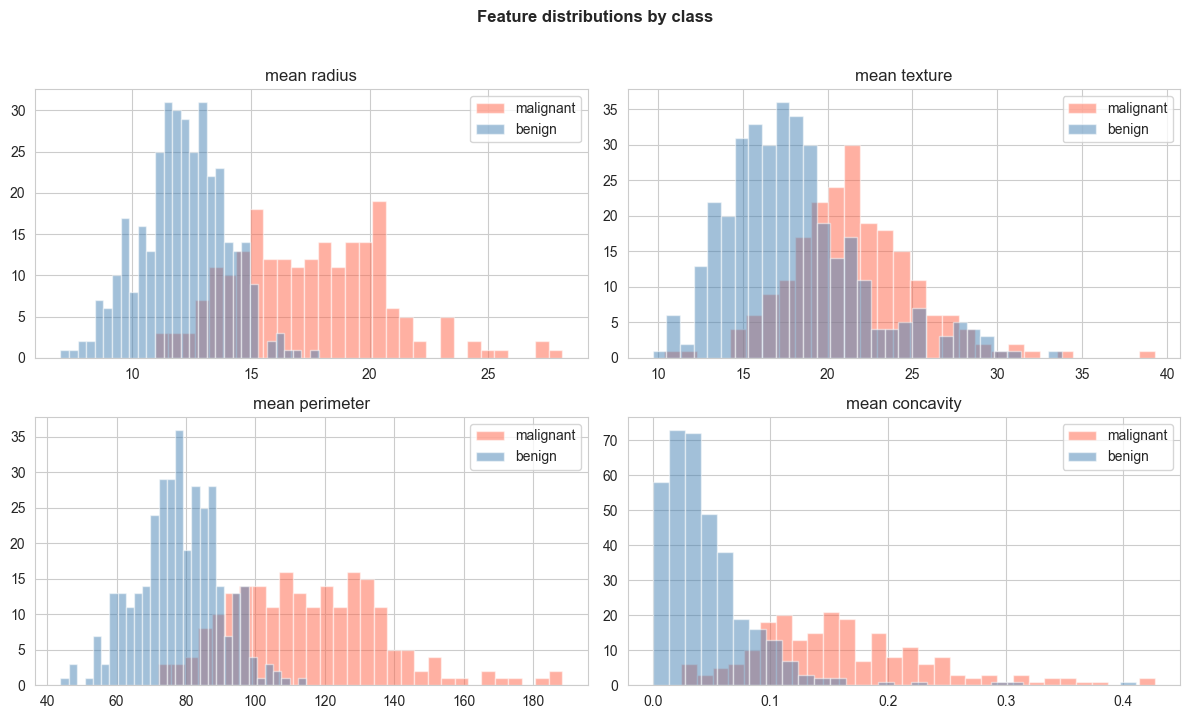

In [34]:
# ── 2c. Feature distributions by class ────────────────────────────────────
df = X.copy(); df['target'] = y

# Pick 4 well-known features
top_feats = ['mean radius', 'mean texture', 'mean perimeter', 'mean concavity']

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, feat in zip(axes.flatten(), top_feats):
    for cls, color, lbl in [(0,'tomato','malignant'), (1,'steelblue','benign')]:
        ax.hist(df[df.target==cls][feat], bins=30, alpha=0.5, color=color, label=lbl)
    ax.set_title(feat); ax.legend()
plt.suptitle('Feature distributions by class', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


### Code Explanation
- For each feature, plot two overlapping histograms — one per class.
- **Heavy overlap** → feature can't separate the classes well.
- **Clear separation** → the model will lean on this feature heavily.


In [35]:
# ── 2d. Correlation with target ───────────────────────────────────────────
target_corr = df.corr()['target'].drop('target').abs().sort_values(ascending=False)
print('Top 10 features by |correlation with target|:')
print(target_corr.head(10).round(3).to_string())


Top 10 features by |correlation with target|:
worst concave points    0.794
worst perimeter         0.783
mean concave points     0.777
worst radius            0.776
mean perimeter          0.743
worst area              0.734
mean radius             0.730
mean area               0.709
mean concavity          0.696
worst concavity         0.660


### Code Explanation
- Take **absolute** correlation — sign doesn't matter, only strength.
- Top correlated features are usually the same ones models will rely on.


---
# 3. Preprocessing + Train/Test Split

For classification, **always use `stratify=y`** in the split so both train and test sets keep the original class proportions.


In [36]:
# ── 3a. Stratified train/test split ───────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y                         # ← keeps class balance equal in train and test
)
print(f'Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}')
print(f'Train class balance:\n{y_train.value_counts(normalize=True).round(3).to_string()}')
print(f'Test  class balance:\n{y_test.value_counts(normalize=True).round(3).to_string()}')


Train: 455  |  Test: 114
Train class balance:
1    0.626
0    0.374
Test  class balance:
1    0.632
0    0.368


### Code Explanation
- `stratify=y` — without it, a random split could happen to put more positives in train than test, biasing your evaluation.
- For severely imbalanced data (1% positive), stratification is non-negotiable.


In [37]:
# ── 3b. Scaling — fit on train only ───────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print('Train mean after scaling:', X_train_s.mean(axis=0)[:3].round(3))   # ~0
print('Train std  after scaling:', X_train_s.std(axis=0)[:3].round(3))    # ~1


Train mean after scaling: [-0.  0. -0.]
Train std  after scaling: [1. 1. 1.]


### Code Explanation
- Same golden rule as regression: `fit_transform` on train, `transform` on test.
- Linear / KNN / SVC need scaled data; tree models do not.


---
# 4. Classification Algorithms

We'll train 8 classifiers on the same split.

### Quick intuition for each

**Logistic Regression** — linear in features, then sigmoid:
$$P(y=1 \mid x) = \sigma(w^Tx + b) = \frac{1}{1 + e^{-(w^Tx + b)}}$$

**Naive Bayes** — uses Bayes' rule, assumes features are independent given the class:
$$P(y \mid x) \propto P(y) \prod_i P(x_i \mid y)$$

**KNN** — predict the majority class among k nearest neighbors (no training, just lookup).

**Decision Tree** — recursively split features that maximize purity (gini / entropy).

**Random Forest** — many trees, each on a bootstrap sample + random feature subset, then vote.

**Gradient Boosting / XGBoost** — train trees sequentially; each fixes the previous tree's mistakes.

**SVC (RBF)** — find the maximum-margin boundary; RBF kernel = "draw curves through points".


In [38]:
# ── 4. Train & evaluate 8 classifiers ─────────────────────────────────────
def cls_score(model, Xtr, ytr, Xte, yte, need_scale=False):
    if need_scale:
        sc = StandardScaler()
        Xtr = sc.fit_transform(Xtr); Xte = sc.transform(Xte)
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1] if hasattr(model, 'predict_proba') else None
    return {
        'Accuracy' : accuracy_score(yte, pred),
        'Precision': precision_score(yte, pred),
        'Recall'   : recall_score(yte, pred),
        'F1'       : f1_score(yte, pred),
        'ROC-AUC'  : roc_auc_score(yte, proba) if proba is not None else np.nan,
        'pred'     : pred,
        'proba'    : proba,
    }

results = {}
results['LogReg']   = cls_score(LogisticRegression(max_iter=5000),     X_train, y_train, X_test, y_test, True)
results['NaiveBayes'] = cls_score(GaussianNB(),                          X_train, y_train, X_test, y_test, True)
results['KNN']      = cls_score(KNeighborsClassifier(n_neighbors=5),   X_train, y_train, X_test, y_test, True)
results['DTree']    = cls_score(DecisionTreeClassifier(max_depth=6, random_state=42),
                                X_train, y_train, X_test, y_test)
results['RF']       = cls_score(RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
                                X_train, y_train, X_test, y_test)
results['GBM']      = cls_score(GradientBoostingClassifier(n_estimators=100, random_state=42),
                                X_train, y_train, X_test, y_test)
results['XGB']      = cls_score(XGBClassifier(n_estimators=200, learning_rate=0.1,
                                               random_state=42, n_jobs=-1, verbosity=0,
                                               use_label_encoder=False, eval_metric='logloss'),
                                X_train, y_train, X_test, y_test)
results['SVC']      = cls_score(SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
                                X_train, y_train, X_test, y_test, True)

summary = pd.DataFrame({k: {m: v[m] for m in ['Accuracy','Precision','Recall','F1','ROC-AUC']}
                        for k, v in results.items()}).T.round(4).sort_values('F1', ascending=False)
print('All classifiers — sorted by F1:')
print(summary)


All classifiers — sorted by F1:
            Accuracy  Precision  Recall      F1  ROC-AUC
LogReg        0.9825     0.9861  0.9861  0.9861   0.9954
SVC           0.9825     0.9861  0.9861  0.9861   0.9950
GBM           0.9561     0.9467  0.9861  0.9660   0.9907
XGB           0.9561     0.9467  0.9861  0.9660   0.9927
KNN           0.9561     0.9589  0.9722  0.9655   0.9788
RF            0.9561     0.9589  0.9722  0.9655   0.9931
NaiveBayes    0.9298     0.9444  0.9444  0.9444   0.9868
DTree         0.9123     0.9559  0.9028  0.9286   0.9147


### Code Explanation — Training all 8 models

- `cls_score()` helper — fit, predict, return all the common metrics in one dict.
- `predict_proba(...)[:, 1]` — probability of the **positive** class. ROC-AUC needs probabilities, not labels.
- Models that need scaling: LogReg, NB, KNN, SVC. Tree-based models don't.
- We sort by **F1** because it balances precision and recall — better than accuracy when classes are imbalanced.


---
# 5. Classification Metrics — Deep Dive

For binary classification, every prediction falls into one of 4 buckets:

|                   | Predicted Positive | Predicted Negative |
|-------------------|--------------------|--------------------|
| **Actual Positive** | True Positive (TP) | False Negative (FN) |
| **Actual Negative** | False Positive (FP) | True Negative (TN) |

### The metrics

| Metric | Formula | What it tells you |
|--------|---------|-------------------|
| **Accuracy** | (TP+TN) / All | % of all predictions correct |
| **Precision** | TP / (TP+FP) | Of predicted positives, how many were really positive? |
| **Recall (Sensitivity)** | TP / (TP+FN) | Of actual positives, how many did we catch? |
| **F1** | 2·P·R / (P+R) | Harmonic mean of P and R |
| **ROC-AUC** | Area under TPR-FPR curve | How well does the model rank positives above negatives? |
| **Log-loss** | −mean(y·log(p)+(1−y)·log(1−p)) | Penalizes confident wrong predictions |

### When to optimize for what?

| Scenario | Optimize | Why |
|----------|----------|-----|
| Spam filter | Precision | Don't put real emails in spam |
| Cancer detection | Recall | Don't miss any cancer cases |
| Balanced problem | F1 or ROC-AUC | Balance both |
| Probabilities matter (calibration) | Log-loss | Wrong-but-confident is much worse than wrong-but-unsure |


In [39]:
# ── 5a. Worked example — manual metric calculations ───────────────────────
# Imagine a small spam classifier predicting on 10 emails
y_true = np.array([1, 0, 1, 1, 0, 1, 0, 0, 1, 0])     # 1 = spam, 0 = ham
y_pred = np.array([1, 1, 1, 0, 0, 1, 0, 0, 1, 1])     # model predictions

cm = confusion_matrix(y_true, y_pred, labels=[1, 0])
tp, fn = cm[0]
fp, tn = cm[1]
print(f'TP={tp}  FN={fn}  FP={fp}  TN={tn}')

acc = (tp+tn) / (tp+tn+fp+fn)
prec = tp / (tp+fp)
rec  = tp / (tp+fn)
f1   = 2*prec*rec / (prec+rec)
print(f'Accuracy  = {acc:.3f}   (manual)   |  sklearn: {accuracy_score(y_true, y_pred):.3f}')
print(f'Precision = {prec:.3f}  (manual)   |  sklearn: {precision_score(y_true, y_pred):.3f}')
print(f'Recall    = {rec:.3f}   (manual)   |  sklearn: {recall_score(y_true, y_pred):.3f}')
print(f'F1        = {f1:.3f}    (manual)   |  sklearn: {f1_score(y_true, y_pred):.3f}')


TP=4  FN=1  FP=2  TN=3
Accuracy  = 0.700   (manual)   |  sklearn: 0.700
Precision = 0.667  (manual)   |  sklearn: 0.667
Recall    = 0.800   (manual)   |  sklearn: 0.800
F1        = 0.727    (manual)   |  sklearn: 0.727


### Code Explanation
- We compute every metric **by hand** from the confusion matrix to demystify the formulas.
- The sklearn output should match exactly.
- Notice we passed `labels=[1, 0]` to `confusion_matrix` so the positive class (1) is the **first row/col** — easier to read in our convention.


---
# 6. Confusion Matrix + ROC + PR Curves

Visual diagnostics — usually the first plots you show stakeholders.


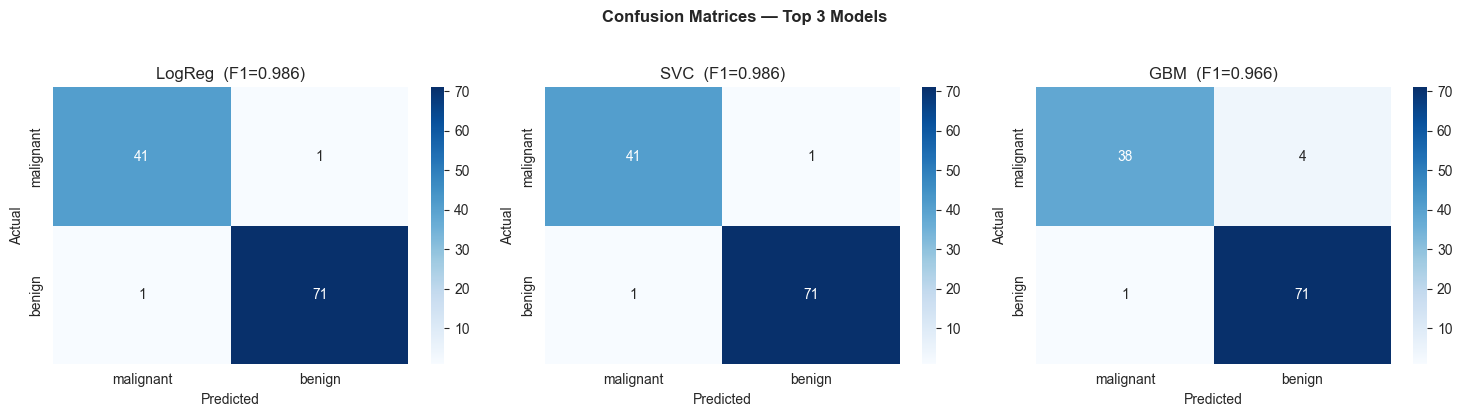

In [40]:
# ── 6a. Confusion matrices for top 3 models ───────────────────────────────
top3 = summary.head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, top3):
    cm = confusion_matrix(y_test, results[name]['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['malignant','benign'],
                yticklabels=['malignant','benign'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'{name}  (F1={results[name]["F1"]:.3f})')
plt.suptitle('Confusion Matrices — Top 3 Models', fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()


### Code Explanation
- `confusion_matrix` returns a 2×2 array — rows=actual, cols=predicted.
- `sns.heatmap(..., annot=True, fmt='d')` — show the count inside each cell.
- Look for **off-diagonal cells** — those are the mistakes.


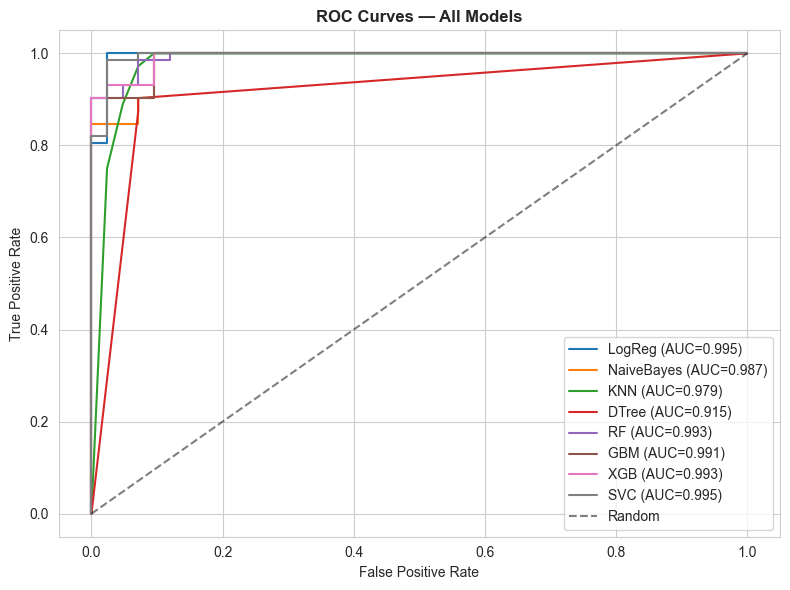

In [41]:
# ── 6b. ROC curves — all models that produce probabilities ────────────────
plt.figure(figsize=(8, 6))
for name, res in results.items():
    if res['proba'] is None: continue
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    auc_v = roc_auc_score(y_test, res['proba'])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_v:.3f})')

plt.plot([0,1], [0,1], 'k--', alpha=0.5, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontweight='bold')
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()


### Code Explanation — ROC Curve

- ROC plots **TPR (recall) vs FPR** across every possible threshold.
- A model that ranks all positives above all negatives traces the top-left corner → AUC = 1.0.
- The diagonal = random guessing → AUC = 0.5.
- AUC is **threshold-independent** — useful when the right threshold isn't known yet.


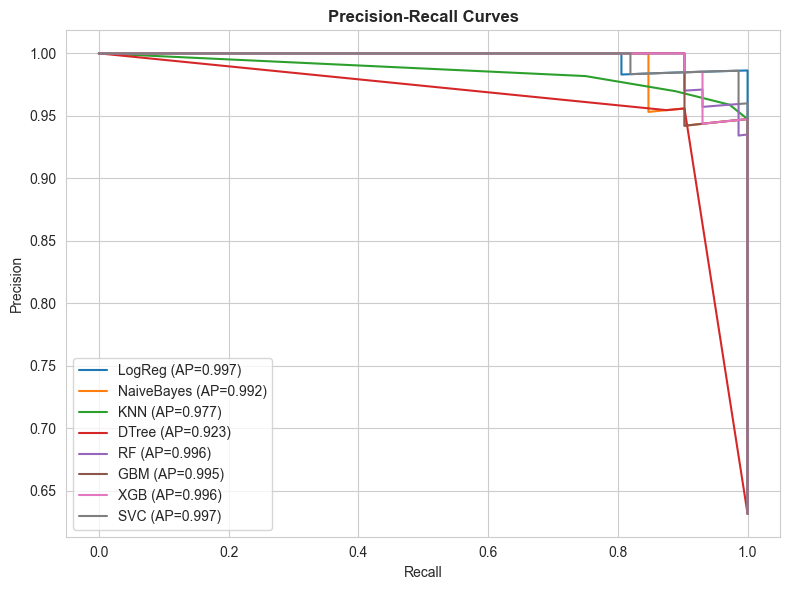

In [42]:
# ── 6c. Precision-Recall curves (better for imbalanced data) ──────────────
plt.figure(figsize=(8, 6))
for name, res in results.items():
    if res['proba'] is None: continue
    p, r, _ = precision_recall_curve(y_test, res['proba'])
    ap = average_precision_score(y_test, res['proba'])
    plt.plot(r, p, label=f'{name} (AP={ap:.3f})')

plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curves', fontweight='bold')
plt.legend(loc='lower left'); plt.tight_layout(); plt.show()


### Code Explanation — PR Curve

- ROC can look great even on heavily imbalanced data — that's misleading.
- **PR curve** plots Precision vs Recall — much harsher when positives are rare.
- **Average Precision (AP)** = area under the PR curve — preferred metric for imbalanced problems.


---
# 7. Handling Class Imbalance

When one class is rare (fraud, cancer, churn), accuracy becomes useless. A model that always predicts "no fraud" can have 99% accuracy — and zero recall.

### Three layers of defense

| Layer | What it does | Built-in? |
|-------|--------------|-----------|
| 1. Pick the right metric | F1 / Recall / PR-AUC, never accuracy | sklearn |
| 2. `class_weight='balanced'` | Inversely weight classes during training | sklearn |
| 3. Resample training set | Oversample minority (SMOTE) or undersample majority | manual or imbalanced-learn |
| 4. Tune the decision threshold | Default 0.5 isn't always right | manual |


In [43]:
# ── 7a. Make a deliberately imbalanced dataset ────────────────────────────
Xi, yi = make_classification(
    n_samples=10000, n_features=15, n_informative=8,
    weights=[0.97, 0.03],            # 97% class 0, 3% class 1 (rare positive)
    random_state=42
)
print(f'Class balance: {pd.Series(yi).value_counts(normalize=True).round(3).to_dict()}')

Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    Xi, yi, test_size=0.2, random_state=42, stratify=yi)


Class balance: {0: 0.965, 1: 0.035}


In [44]:
# ── 7b. Naive vs class-weight-balanced model ─────────────────────────────
# Baseline — no imbalance handling
m1 = LogisticRegression(max_iter=5000).fit(Xi_train, yi_train)
p1 = m1.predict(Xi_test)
print('--- Naive (no handling) ---')
print(classification_report(yi_test, p1, digits=3))

# class_weight='balanced' — re-weights loss inversely to class frequency
m2 = LogisticRegression(max_iter=5000, class_weight='balanced').fit(Xi_train, yi_train)
p2 = m2.predict(Xi_test)
print('--- class_weight="balanced" ---')
print(classification_report(yi_test, p2, digits=3))


--- Naive (no handling) ---
              precision    recall  f1-score   support

           0      0.965     1.000     0.982      1930
           1      0.000     0.000     0.000        70

    accuracy                          0.965      2000
   macro avg      0.482     0.500     0.491      2000
weighted avg      0.931     0.965     0.948      2000

--- class_weight="balanced" ---
              precision    recall  f1-score   support

           0      0.986     0.695     0.816      1930
           1      0.080     0.729     0.144        70

    accuracy                          0.697      2000
   macro avg      0.533     0.712     0.480      2000
weighted avg      0.954     0.697     0.792      2000



### Code Explanation
- Without handling, the model achieves high **accuracy** but recall on the rare class is near zero.
- `class_weight='balanced'` boosts recall at the cost of precision (more false positives, fewer false negatives).
- Choose based on the cost of each error type.


In [45]:
# ── 7c. Manual oversampling (SMOTE-style by simple duplication+jitter) ────
def naive_oversample(X, y, random_state=42):
    '''Duplicate minority-class rows with light Gaussian jitter — a stand-in for SMOTE.'''
    rng = np.random.default_rng(random_state)
    classes, counts = np.unique(y, return_counts=True)
    majority_count = counts.max()
    Xs, ys = [X], [y]
    for cls, cnt in zip(classes, counts):
        if cnt < majority_count:
            n_extra = majority_count - cnt
            idx = rng.choice(np.where(y == cls)[0], size=n_extra, replace=True)
            X_add = X[idx] + rng.normal(0, 0.01, size=(n_extra, X.shape[1]))   # tiny jitter
            Xs.append(X_add)
            ys.append(np.full(n_extra, cls))
    return np.vstack(Xs), np.concatenate(ys)

X_bal, y_bal = naive_oversample(Xi_train, yi_train)
print(f'Before oversample: {pd.Series(yi_train).value_counts().to_dict()}')
print(f'After  oversample: {pd.Series(y_bal).value_counts().to_dict()}')

m3 = LogisticRegression(max_iter=5000).fit(X_bal, y_bal)
p3 = m3.predict(Xi_test)
print('--- After oversampling minority class ---')
print(classification_report(yi_test, p3, digits=3))


Before oversample: {0: 7722, 1: 278}
After  oversample: {0: 7722, 1: 7722}
--- After oversampling minority class ---
              precision    recall  f1-score   support

           0      0.986     0.695     0.815      1930
           1      0.080     0.729     0.144        70

    accuracy                          0.696      2000
   macro avg      0.533     0.712     0.479      2000
weighted avg      0.954     0.696     0.792      2000



### Code Explanation — Manual Oversampling

- Real **SMOTE** creates synthetic minority points by interpolating between neighbors.
- This simpler version duplicates rows + adds tiny Gaussian jitter — captures the same idea without the `imbalanced-learn` dependency.
- After balancing, the model sees equal counts → recall improves substantially.
- **Important:** only oversample the **training set**, never the test set.


Default threshold = 0.50 → F1 = 0.000
Best threshold   = 0.128 → F1 = 0.381


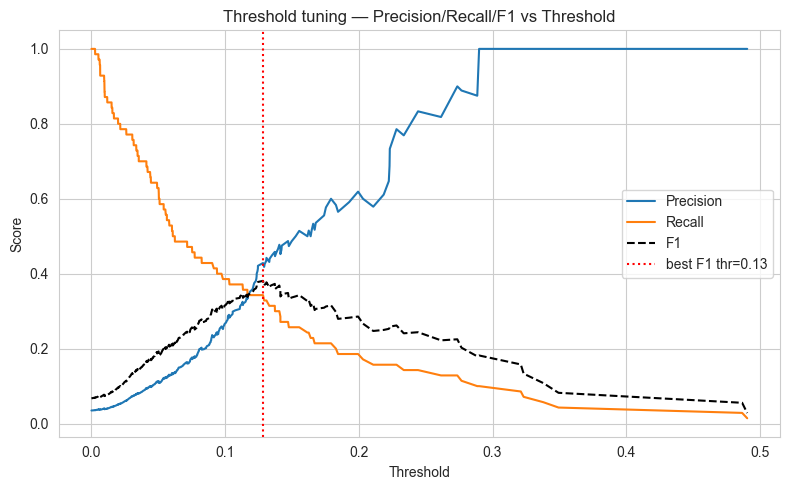

In [46]:
# ── 7d. Threshold tuning via the Precision-Recall curve ──────────────────
proba = m1.predict_proba(Xi_test)[:, 1]
prec, rec, thr = precision_recall_curve(yi_test, proba)
f1_curve = 2 * prec * rec / (prec + rec + 1e-9)            # +epsilon avoids div-by-zero
best_idx = f1_curve.argmax()
best_thr = thr[best_idx]

print(f'Default threshold = 0.50 → F1 = {f1_score(yi_test, m1.predict(Xi_test)):.3f}')
print(f'Best threshold   = {best_thr:.3f} → F1 = {f1_curve[best_idx]:.3f}')

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thr, prec[:-1], label='Precision')
ax.plot(thr, rec[:-1],  label='Recall')
ax.plot(thr, f1_curve[:-1], label='F1', linestyle='--', color='black')
ax.axvline(best_thr, color='red', linestyle=':', label=f'best F1 thr={best_thr:.2f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Threshold tuning — Precision/Recall/F1 vs Threshold')
ax.legend(); plt.tight_layout(); plt.show()


### Code Explanation — Threshold Tuning

- The default 0.5 cutoff is **arbitrary** — sklearn just picks it for you.
- Sweep thresholds and pick the one that maximizes your business metric (F1 here).
- For fraud, you might pick the threshold that achieves at least 90% recall, accepting low precision.


---
# 8. Cross-Validation + Hyperparameter Tuning

For classification we use **StratifiedKFold** — each fold preserves the class proportions.


In [47]:
# ── 8a. 5-fold Stratified CV on top 3 models ──────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'LogReg' : Pipeline([('s', StandardScaler()),
                         ('m', LogisticRegression(max_iter=5000))]),
    'RF'     : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGB'    : XGBClassifier(n_estimators=200, learning_rate=0.1, random_state=42,
                              n_jobs=-1, verbosity=0, use_label_encoder=False,
                              eval_metric='logloss'),
}

cv_rows = []
for name, model in cv_models.items():
    f1s  = cross_val_score(model, X, y, cv=skf, scoring='f1',      n_jobs=-1)
    aucs = cross_val_score(model, X, y, cv=skf, scoring='roc_auc', n_jobs=-1)
    cv_rows.append({
        'Model'    : name,
        'Mean F1'  : f1s.mean().round(4),
        'Std F1'   : f1s.std().round(4),
        'Mean AUC' : aucs.mean().round(4),
    })
print('5-Fold Stratified CV results:')
print(pd.DataFrame(cv_rows).to_string(index=False))


5-Fold Stratified CV results:
 Model  Mean F1  Std F1  Mean AUC
LogReg   0.9794  0.0127    0.9954
    RF   0.9637  0.0080    0.9896
   XGB   0.9709  0.0065    0.9939


### Code Explanation
- `StratifiedKFold` ensures each fold has the same class proportion as the full dataset.
- `scoring='f1'` / `'roc_auc'` — pick the metric your business cares about.
- Low std → stable model. High std → maybe overfitting or unstable on small data.


In [48]:
# ── 8b. GridSearchCV on Logistic Regression ───────────────────────────────
log_pipe = Pipeline([('s', StandardScaler()), ('m', LogisticRegression(max_iter=5000))])

grid = GridSearchCV(
    log_pipe,
    param_grid = {
        'm__C'      : [0.01, 0.1, 1.0, 10.0],       # inverse regularization strength
        'm__penalty': ['l2'],                        # L1 needs solver='liblinear'
    },
    cv=5, scoring='f1', n_jobs=-1
)
grid.fit(X_train, y_train)
print('Best params:', grid.best_params_)
print(f'Best CV F1 : {grid.best_score_:.4f}')
print(f'Test F1    : {f1_score(y_test, grid.predict(X_test)):.4f}')


Best params: {'m__C': 0.1, 'm__penalty': 'l2'}
Best CV F1 : 0.9845
Test F1    : 0.9793


In [49]:
# ── 8c. RandomizedSearchCV on Random Forest ──────────────────────────────
from scipy.stats import randint

rand = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions = {
        'n_estimators'     : randint(100, 400),
        'max_depth'        : [None, 5, 10, 20],
        'min_samples_split': randint(2, 20),
        'max_features'     : ['sqrt', 'log2'],
    },
    n_iter=15, cv=3, scoring='f1', random_state=42, n_jobs=-1
)
rand.fit(X_train, y_train)
print('Best params:', rand.best_params_)
print(f'Best CV F1 : {rand.best_score_:.4f}')
print(f'Test F1    : {f1_score(y_test, rand.predict(X_test)):.4f}')


Best params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 4, 'n_estimators': 234}
Best CV F1 : 0.9702
Test F1    : 0.9583


### Code Explanation
- `GridSearchCV`: exhaustive — fine for small grids.
- `RandomizedSearchCV`: samples from distributions — required when the search space is large.
- `m__C` / `m__penalty` — pipeline syntax (`step__param`).


---
# 9. Project 1 — Customer Churn Prediction

**Problem:** A telecom company wants to know which customers are about to cancel their subscription, so retention offers can be targeted.

**Target:** `churn` — 1 (left) / 0 (stayed).
**Imbalance:** ~25% churn — moderate.

We'll generate a realistic synthetic dataset.


In [50]:
# ── 9a. Generate synthetic churn dataset ──────────────────────────────────
rng = np.random.default_rng(7)
n = 5000

tenure          = rng.integers(0, 72, size=n)                       # months as customer
monthly_charges = rng.uniform(20, 120, size=n).round(2)             # $/month
total_charges   = (tenure * monthly_charges + rng.normal(0, 50, n)).clip(0)
contract        = rng.choice(['Month-to-month','One year','Two year'],
                              size=n, p=[0.55, 0.25, 0.20])
internet        = rng.choice(['DSL','Fiber','None'], size=n, p=[0.4,0.45,0.15])
payment         = rng.choice(['Electronic check','Mailed check',
                              'Bank transfer','Credit card'],
                              size=n, p=[0.4, 0.2, 0.2, 0.2])
support_calls   = rng.poisson(1.0, size=n)
senior          = rng.choice([0, 1], size=n, p=[0.85, 0.15])

# Build the underlying churn probability — these effects mimic reality
contract_eff = pd.Series(contract).map({'Month-to-month':0.25,'One year':-0.05,'Two year':-0.18}).values
internet_eff = pd.Series(internet).map({'DSL':-0.02,'Fiber':0.08,'None':-0.05}).values
prob = 0.20 + contract_eff + internet_eff \
       + 0.04 * support_calls - 0.005 * tenure + 0.001 * monthly_charges \
       + 0.06 * senior + rng.normal(0, 0.05, n)
prob = np.clip(prob, 0.01, 0.95)
churn = (rng.random(n) < prob).astype(int)

churn_df = pd.DataFrame({
    'tenure': tenure, 'monthly_charges': monthly_charges, 'total_charges': total_charges,
    'contract': contract, 'internet': internet, 'payment': payment,
    'support_calls': support_calls, 'senior': senior,
    'churn': churn
})
print(f'Shape: {churn_df.shape}')
print(f'Churn rate: {churn_df.churn.mean()*100:.1f}%')
churn_df.head()


Shape: (5000, 9)
Churn rate: 25.9%


,tenure,monthly_charges,total_charges,contract,internet,payment,support_calls,senior,churn
0,68,81.44,5553.379444,Two year,Fiber,Bank transfer,0,1,0
1,45,86.39,3840.842904,Month-to-month,Fiber,Electronic check,1,0,0
2,49,81.39,3938.321259,Month-to-month,DSL,Electronic check,0,0,0
3,64,45.62,2931.130888,Month-to-month,Fiber,Electronic check,1,0,0
4,41,57.63,2281.560315,Two year,None,Electronic check,2,0,0


### Code Explanation
- Realistic effects: month-to-month contracts churn more, long tenure churns less, support calls signal frustration.
- We add `rng.normal(0, 0.05, n)` noise so the relationship isn't perfectly learnable.
- `(rng.random(n) < prob).astype(int)` — stochastic churn outcomes given the underlying probability.


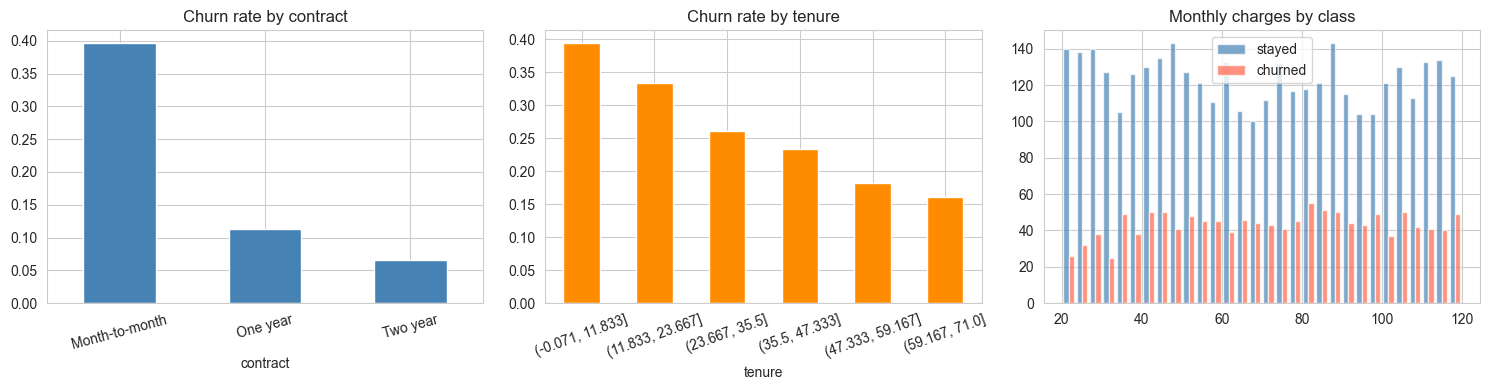

In [51]:
# ── 9b. Quick EDA — churn by contract type ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

churn_df.groupby('contract')['churn'].mean().plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('Churn rate by contract'); axes[0].tick_params(axis='x', rotation=15)

churn_df.groupby(pd.cut(churn_df['tenure'], 6))['churn'].mean().plot.bar(ax=axes[1], color='darkorange')
axes[1].set_title('Churn rate by tenure'); axes[1].tick_params(axis='x', rotation=20)

axes[2].hist([churn_df[churn_df.churn==0]['monthly_charges'],
              churn_df[churn_df.churn==1]['monthly_charges']],
             bins=30, label=['stayed','churned'], color=['steelblue','tomato'], alpha=0.7)
axes[2].set_title('Monthly charges by class'); axes[2].legend()
plt.tight_layout(); plt.show()


In [52]:
# ── 9c. Preprocessing pipeline + 3-model comparison ───────────────────────
num_cols = ['tenure','monthly_charges','total_charges','support_calls','senior']
cat_cols = ['contract','internet','payment']

prep = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols),
])

X_c = churn_df.drop(columns=['churn']); y_c = churn_df['churn']
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_c, y_c, test_size=0.2, random_state=42, stratify=y_c)

models = {
    'LogReg' : Pipeline([('p', prep), ('m', LogisticRegression(max_iter=5000, class_weight='balanced'))]),
    'RF'     : Pipeline([('p', prep), ('m', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight='balanced'))]),
    'XGB'    : Pipeline([('p', prep), ('m', XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
                                                          random_state=42, n_jobs=-1, verbosity=0,
                                                          use_label_encoder=False, eval_metric='logloss',
                                                          scale_pos_weight=(yc_tr==0).sum()/(yc_tr==1).sum()))]),
}

rows = []
preds = {}
for name, pipe in models.items():
    pipe.fit(Xc_tr, yc_tr)
    p = pipe.predict(Xc_te)
    pr = pipe.predict_proba(Xc_te)[:, 1]
    preds[name] = (p, pr)
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(yc_te, p),
        'Precision': precision_score(yc_te, p),
        'Recall': recall_score(yc_te, p),
        'F1': f1_score(yc_te, p),
        'AUC': roc_auc_score(yc_te, pr),
    })
print('Customer Churn — model comparison:')
print(pd.DataFrame(rows).round(4).to_string(index=False))


Customer Churn — model comparison:
 Model  Accuracy  Precision  Recall     F1    AUC
LogReg     0.689     0.4425  0.7722 0.5626 0.7664
    RF     0.730     0.4671  0.3012 0.3662 0.7157
   XGB     0.680     0.4279  0.6988 0.5308 0.7449


### Code Explanation
- `class_weight='balanced'` for LogReg & RF.
- `scale_pos_weight` does the same for XGBoost: ratio of negatives to positives.
- `ColumnTransformer` lets us scale numerics and one-hot categoricals in one step.


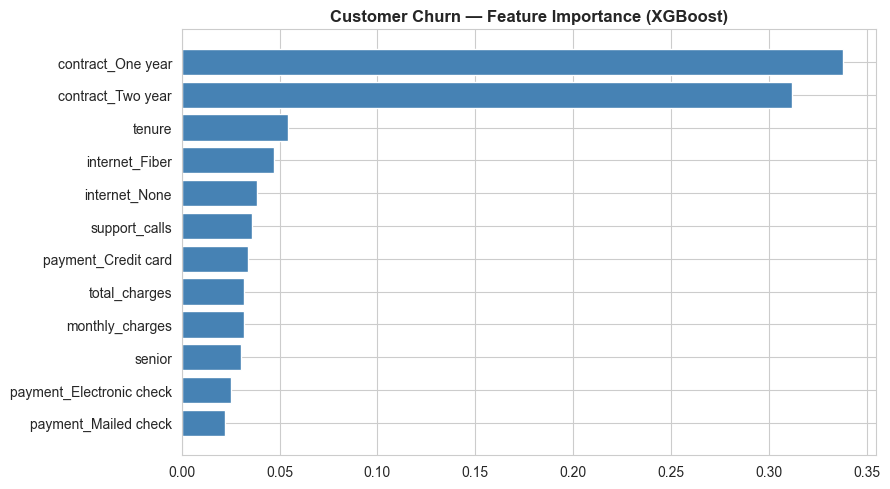

In [53]:
# ── 9d. Feature importance from the best model (XGBoost) ──────────────────
xgb_model = models['XGB']
ohe = xgb_model.named_steps['p'].named_transformers_['cat']
feat_names = num_cols + list(ohe.get_feature_names_out(cat_cols))

imp = pd.DataFrame({
    'feature': feat_names,
    'importance': xgb_model.named_steps['m'].feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(imp['feature'], imp['importance'], color='steelblue')
plt.title('Customer Churn — Feature Importance (XGBoost)', fontweight='bold')
plt.tight_layout(); plt.show()


### Project 1 Summary
- The strongest churn drivers tend to be **contract type** and **tenure** — exactly what telecom retention teams target.
- Use the model's **probability** rather than the binary prediction in production: rank customers by churn risk and offer retention discounts to the top N%.


---
# 10. Project 2 — Credit Risk Model

**Problem:** Predict whether a loan applicant will **default** (1) or repay (0).

**Stakes:** Bank wants to minimize default loss but also approve enough loans.
**Metric focus:** AUC and Recall (catching defaulters), with Precision as a secondary check.


In [54]:
# ── 10a. Generate synthetic credit dataset ────────────────────────────────
rng = np.random.default_rng(13)
n = 5000

age            = rng.integers(21, 70, size=n)
income         = (rng.lognormal(10.5, 0.6, n) + 5000).round(0)        # $
loan_amount    = rng.uniform(1000, 50000, n).round(0)
loan_term      = rng.choice([12, 24, 36, 48, 60], size=n)
employed_yrs   = rng.integers(0, 30, size=n)
existing_loans = rng.poisson(0.7, n)
home_ownership = rng.choice(['rent','mortgage','own'], size=n, p=[0.4, 0.45, 0.15])
purpose        = rng.choice(['debt','home','car','education','other'],
                             size=n, p=[0.3,0.2,0.2,0.15,0.15])
credit_score   = (rng.normal(680, 80, n)).clip(300, 850).round(0)

# default probability — credit_score & income protect, loans & high amount hurt
prob = 0.4 - 0.0005 * credit_score + 0.000005 * loan_amount \
       - 0.000003 * income + 0.05 * existing_loans \
       - 0.005 * employed_yrs + rng.normal(0, 0.07, n)
prob = np.clip(prob, 0.01, 0.95)
default = (rng.random(n) < prob).astype(int)

credit_df = pd.DataFrame({
    'age': age, 'income': income, 'loan_amount': loan_amount, 'loan_term': loan_term,
    'employed_yrs': employed_yrs, 'existing_loans': existing_loans,
    'home_ownership': home_ownership, 'purpose': purpose, 'credit_score': credit_score,
    'default': default,
})
print(f'Default rate: {credit_df.default.mean()*100:.1f}%')
credit_df.head()


Default rate: 6.7%


,age,income,loan_amount,loan_term,employed_yrs,existing_loans,home_ownership,purpose,credit_score,default
0,64,38617.0,11161.0,24,5,1,rent,home,648.0,0
1,63,27382.0,22013.0,24,24,0,rent,debt,726.0,0
2,61,23667.0,41460.0,24,28,1,rent,home,680.0,0
3,62,25714.0,12818.0,48,19,1,rent,debt,564.0,0
4,24,19103.0,42647.0,60,25,1,mortgage,car,623.0,0


In [55]:
# ── 10b. Pipeline + LogReg / RF / XGB ─────────────────────────────────────
num_cols_c = ['age','income','loan_amount','loan_term','employed_yrs','existing_loans','credit_score']
cat_cols_c = ['home_ownership','purpose']

prep_c = ColumnTransformer([
    ('num', StandardScaler(), num_cols_c),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols_c),
])

Xcr = credit_df.drop(columns=['default']); ycr = credit_df['default']
Xcr_tr, Xcr_te, ycr_tr, ycr_te = train_test_split(Xcr, ycr, test_size=0.2, random_state=42, stratify=ycr)

cred_models = {
    'LogReg': Pipeline([('p', prep_c), ('m', LogisticRegression(max_iter=5000, class_weight='balanced'))]),
    'RF'    : Pipeline([('p', prep_c), ('m', RandomForestClassifier(n_estimators=300, random_state=42,
                                                                     n_jobs=-1, class_weight='balanced'))]),
    'XGB'   : Pipeline([('p', prep_c), ('m', XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
                                                            random_state=42, n_jobs=-1, verbosity=0,
                                                            use_label_encoder=False, eval_metric='logloss'))]),
}

rows = []
for name, pipe in cred_models.items():
    pipe.fit(Xcr_tr, ycr_tr)
    p  = pipe.predict(Xcr_te)
    pr = pipe.predict_proba(Xcr_te)[:, 1]
    rows.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(ycr_te, p),
        'Precision': precision_score(ycr_te, p),
        'Recall'   : recall_score(ycr_te, p),
        'F1'       : f1_score(ycr_te, p),
        'AUC'      : roc_auc_score(ycr_te, pr),
    })
print('Credit Risk — comparison:')
print(pd.DataFrame(rows).round(4).to_string(index=False))


Credit Risk — comparison:
 Model  Accuracy  Precision  Recall     F1    AUC
LogReg     0.669     0.1393  0.7612 0.2356 0.7758
    RF     0.933     0.0000  0.0000 0.0000 0.7198
   XGB     0.933     0.5000  0.0299 0.0563 0.7085


In [56]:
# ── 10c. Threshold tuning — pick threshold that achieves recall ≥ 0.7 ─────
xgb_pipe = cred_models['XGB']
proba    = xgb_pipe.predict_proba(Xcr_te)[:, 1]
prec, rec, thr = precision_recall_curve(ycr_te, proba)

# find largest threshold where recall >= 0.7
mask = rec[:-1] >= 0.7
if mask.any():
    chosen_thr = thr[mask].max()
else:
    chosen_thr = 0.5

p_strict = (proba >= chosen_thr).astype(int)
print(f'Default threshold (0.5):  Recall={recall_score(ycr_te, xgb_pipe.predict(Xcr_te)):.3f}')
print(f'Tuned threshold ({chosen_thr:.3f}): Recall={recall_score(ycr_te, p_strict):.3f}, '
      f'Precision={precision_score(ycr_te, p_strict):.3f}, F1={f1_score(ycr_te, p_strict):.3f}')


Default threshold (0.5):  Recall=0.030
Tuned threshold (0.035): Recall=0.701, Precision=0.108, F1=0.187


### Project 2 Summary
- For credit risk, **recall on defaulters** matters most — a missed default costs more than a false alarm.
- Tuning the threshold lets you trade precision for recall without retraining.
- In production: combine model score with rule-based filters (KYC, employment verification).


---
# 11. Project 3 — Fraud Detection (Imbalanced)

**Problem:** Detect fraudulent credit card transactions in a stream where < 1% are fraud.

**Why this is hard:**
- Extreme imbalance — predicting "all clean" gives 99% accuracy but catches 0 fraud
- Fraudsters change tactics — concept drift over time
- Cost asymmetry — missing one fraud (FN) costs more than blocking a legit transaction (FP)

**Plan:** synthetic fraud dataset + class_weight + manual oversample + threshold tuning.


In [57]:
# ── 11a. Generate severely imbalanced fraud dataset ───────────────────────
Xf, yf = make_classification(
    n_samples=20000, n_features=20, n_informative=12,
    n_redundant=4, n_clusters_per_class=2,
    weights=[0.99, 0.01],                          # 1% fraud
    flip_y=0.01, class_sep=1.2, random_state=42,
)
print(f'Class balance: {pd.Series(yf).value_counts().to_dict()}  (≈1% fraud)')

Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(Xf, yf, test_size=0.2,
                                               random_state=42, stratify=yf)


Class balance: {0: 19688, 1: 312}  (≈1% fraud)


In [58]:
# ── 11b. Three approaches: naive / class_weight / oversample ──────────────
from copy import deepcopy

results_f = {}

# (1) naive
m_naive = XGBClassifier(n_estimators=200, random_state=42, n_jobs=-1, verbosity=0,
                         use_label_encoder=False, eval_metric='logloss').fit(Xf_tr, yf_tr)
results_f['Naive'] = m_naive

# (2) scale_pos_weight (XGBoost equivalent of class_weight)
neg, pos = (yf_tr==0).sum(), (yf_tr==1).sum()
m_cw = XGBClassifier(n_estimators=200, scale_pos_weight=neg/pos,
                      random_state=42, n_jobs=-1, verbosity=0,
                      use_label_encoder=False, eval_metric='logloss').fit(Xf_tr, yf_tr)
results_f['ClassWeight'] = m_cw

# (3) manual oversample
Xb, yb = naive_oversample(Xf_tr, yf_tr)
m_os = XGBClassifier(n_estimators=200, random_state=42, n_jobs=-1, verbosity=0,
                      use_label_encoder=False, eval_metric='logloss').fit(Xb, yb)
results_f['Oversample'] = m_os

rows = []
for name, m in results_f.items():
    p  = m.predict(Xf_te)
    pr = m.predict_proba(Xf_te)[:, 1]
    rows.append({
        'Approach' : name,
        'Accuracy' : accuracy_score(yf_te, p),
        'Precision': precision_score(yf_te, p),
        'Recall'   : recall_score(yf_te, p),
        'F1'       : f1_score(yf_te, p),
        'AUC'      : roc_auc_score(yf_te, pr),
        'AvgPrec'  : average_precision_score(yf_te, pr),
    })
fraud_df_results = pd.DataFrame(rows).round(4)
print('Fraud Detection — three approaches:')
print(fraud_df_results.to_string(index=False))


Fraud Detection — three approaches:
   Approach  Accuracy  Precision  Recall     F1    AUC  AvgPrec
      Naive    0.9880     0.9375  0.2419 0.3846 0.7121   0.3677
ClassWeight    0.9878     1.0000  0.2097 0.3467 0.7441   0.3613
 Oversample    0.9865     0.7222  0.2097 0.3250 0.7134   0.3254


### Code Explanation
- **Accuracy is misleading** — it's high for all three because 99% of transactions are clean.
- The right metrics here are **Recall** (catch fraud) and **Average Precision** (PR-AUC).
- `scale_pos_weight = #negatives / #positives` is XGBoost's built-in imbalance fix.


Threshold tuned to 0.000 → Recall=0.855, Precision=0.020, F1=0.039


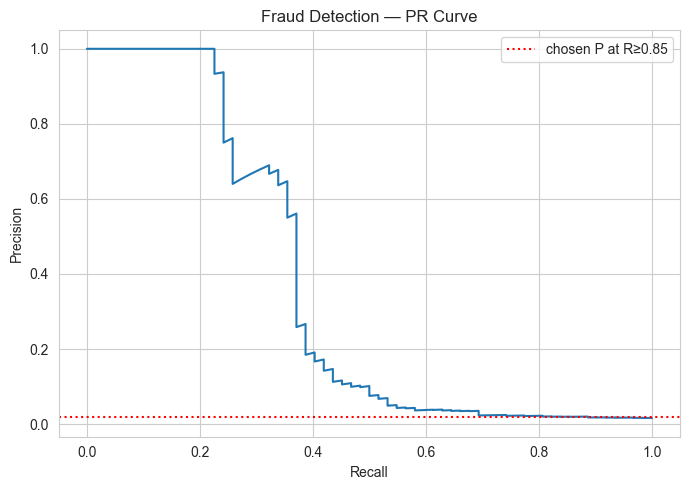

In [59]:
# ── 11c. Threshold tuning to hit a recall target ──────────────────────────
best_model = results_f['ClassWeight']
proba = best_model.predict_proba(Xf_te)[:, 1]
prec, rec, thr = precision_recall_curve(yf_te, proba)

# Note: precision_recall_curve returns prec/rec of length N+1 and thr of length N.
# Align all three by dropping the last (sentinel) prec/rec point.
prec_aligned = prec[:-1]
rec_aligned  = rec[:-1]
mask = rec_aligned >= 0.85

if mask.any():
    chosen_thr  = thr[mask].max()                  # highest thr that still hits the recall target
    chosen_prec = prec_aligned[mask].max()         # corresponding precision (for the plot line)
    pf = (proba >= chosen_thr).astype(int)
    print(f'Threshold tuned to {chosen_thr:.3f} → '
          f'Recall={recall_score(yf_te, pf):.3f}, '
          f'Precision={precision_score(yf_te, pf):.3f}, '
          f'F1={f1_score(yf_te, pf):.3f}')
else:
    chosen_prec = 0
    print('Recall target not achievable on this model.')

# PR curve visualisation
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rec, prec)
ax.axhline(y=chosen_prec, color='red', linestyle=':',
           label='chosen P at R≥0.85')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Fraud Detection — PR Curve')
ax.legend(); plt.tight_layout(); plt.show()


### Project 3 Summary
- All three handling strategies catch more fraud than the naive model, but at the cost of more false alarms.
- In production, combine: high-recall model → human review queue → updates back into training.
- Track **Average Precision** over time — concept drift can erode it silently.


---
# 12. Project 4 — Recommendation System (Content-Based)

**Note:** Recommendation isn't strictly classification, but it commonly uses classification-style techniques (e.g. "will this user click this item?"). Two main flavors:

| Type | Idea |
|------|------|
| Content-based | Recommend items **similar in content** to what the user liked |
| Collaborative filtering | Recommend items that **similar users** liked |
| Hybrid | Combine both |

Here we'll build a **content-based** movie recommender using TF-IDF on movie descriptions + cosine similarity.


### What is this system actually doing?

In one sentence: **given a movie you liked, find other movies whose descriptions use similar words.**

It does this in 3 steps:

#### Step 1 — Turn each description into numbers (TF-IDF)

We can't compare strings mathematically. So each movie description becomes a **vector** where each position is one word in the vocabulary, and the value tells us **how distinctive that word is to that movie**.

```
Vocabulary (sample): [action, alien, animation, crime, hacker, horror, mafia, sci-fi, space, ...]

"hacker discovers reality simulation action sci-fi"
       ↓ TF-IDF
   [0.42, 0.0, 0.0, 0.0, 0.51, 0.0, 0.0, 0.38, 0.0, ...]
    action       hacker          sci-fi

"toys come to life adventure friendship animation kids"
       ↓ TF-IDF
   [0.0, 0.0, 0.55, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...]
              animation
```

- **TF (term frequency)** = how often the word appears in *this* movie
- **IDF (inverse doc freq)** = down-weights words appearing in *many* movies
- Result: distinctive words (like `hacker`, `mafia`) get high values; generic words get low ones

#### Step 2 — Measure how close two vectors point (cosine similarity)

$$\text{cos}(A, B) = \frac{A \cdot B}{\|A\| \, \|B\|}$$

| Value | Meaning |
|-------|---------|
| 1.0 | Identical word patterns |
| 0.5 | Some shared words |
| 0.0 | No shared words |

`cosine_similarity(matrix)` produces a **17×17 grid** where cell `[i,j]` = similarity between movie `i` and movie `j`. Diagonal = 1.0 (each movie matches itself).

#### Step 3 — Return top-N nearest neighbors for the given movie

For "The Matrix": grab its row from the similarity matrix → sort descending → skip itself → return the top 5. They'll be the movies whose descriptions share the most distinctive words with the Matrix's description (`hacker`, `sci-fi`, `action`).

#### Why "content-based"?

It only looks at **item content** (the description). It does **not** use:
- What other users watched → that would be **collaborative filtering**
- Ratings or clicks → that would need user history

Advantage: works for brand-new users (no history needed) — just give it one item they liked.
Limitation: only recommends similar content — won't surface diverse picks the way collaborative filtering can.

---

### Mini worked example — peek at the actual numbers

Run the next two cells to see the TF-IDF values and the cosine calculation done by hand on 3 movies.

In [60]:
# ── 12a. Tiny synthetic movie corpus (descriptions) ───────────────────────
movies = pd.DataFrame({
    'title': [
        'The Matrix', 'Inception', 'Interstellar', 'The Dark Knight',
        'Toy Story', 'Finding Nemo', 'The Lion King', 'Frozen',
        'The Godfather', 'Pulp Fiction', 'Goodfellas',
        'Pride and Prejudice', 'Notting Hill', 'La La Land',
        'Alien', 'The Thing', 'Hereditary',
    ],
    'description': [
        'hacker discovers reality is a simulation virtual world action sci-fi',
        'thief enters dreams to plant ideas heist mind action sci-fi',
        'astronauts travel through wormhole to save humanity space sci-fi',
        'dark crime fighter battles psychotic villain in gotham action thriller',
        'toys come to life adventure friendship animation kids',
        'fish father searches for son ocean adventure animation kids',
        'lion cub becomes king africa animation animals music',
        'magical sisters ice powers princess animation music',
        'mafia family drama crime power patriarch',
        'crime stories interweave drugs hitmen gangsters quirky',
        'real life mafia rise and fall crime violence',
        'romance regency love marriage misunderstandings literary',
        'romantic comedy bookstore london love',
        'aspiring actress and jazz musician love music dreams',
        'space crew encounters terrifying alien creature horror sci-fi',
        'antarctic researchers face shapeshifting alien horror sci-fi',
        'family tragedy dark supernatural horror grief',
    ],
})
print(f'Catalog size: {len(movies)} movies')


Catalog size: 17 movies


In [61]:
# ── 12b. TF-IDF vectorize the descriptions ────────────────────────────────
tfidf = TfidfVectorizer(stop_words='english')
matrix = tfidf.fit_transform(movies['description'])
print(f'TF-IDF matrix shape: {matrix.shape}  (movies × terms)')


TF-IDF matrix shape: (17, 95)  (movies × terms)


### Code Explanation — TF-IDF

- **TF (Term Frequency)** — how often a word appears in this document
- **IDF (Inverse Document Frequency)** — down-weights words that appear in many documents (`the`, `of`)
- Result: each movie becomes a vector emphasizing words that are **distinctive** for it
- `stop_words='english'` removes common filler words


In [62]:
# ── 12c. Compute cosine similarity matrix ─────────────────────────────────
from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity(matrix)
print(f'Similarity matrix shape: {sim.shape}')


Similarity matrix shape: (17, 17)


### Code Explanation — Cosine Similarity

$$\text{cos}(A, B) = \frac{A \cdot B}{\|A\| \|B\|}$$

- Range: −1 to 1 (for TF-IDF, 0 to 1 since values are non-negative)
- 1.0 = identical word distributions, 0.0 = no overlap
- Robust to document length — only the **direction** of the vector matters, not its magnitude


In [63]:
# ── 12d. Recommendation function ──────────────────────────────────────────
def recommend(title, top_n=5):
    if title not in movies['title'].values:
        return f'"{title}" not in catalog.'
    idx = movies.index[movies['title'] == title][0]
    scores = list(enumerate(sim[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:top_n+1]   # skip self
    return pd.DataFrame([
        {'title': movies.iloc[i]['title'], 'similarity': round(s, 3)}
        for i, s in scores
    ])

print('--- Recommendations for "The Matrix" ---')
print(recommend('The Matrix'))

print('\n--- Recommendations for "Toy Story" ---')
print(recommend('Toy Story'))

print('\n--- Recommendations for "The Godfather" ---')
print(recommend('The Godfather'))


--- Recommendations for "The Matrix" ---
             title  similarity
0        Inception       0.188
1        The Thing       0.126
2     Interstellar       0.122
3            Alien       0.119
4  The Dark Knight       0.080

--- Recommendations for "Toy Story" ---
           title  similarity
0   Finding Nemo       0.319
1     Goodfellas       0.129
2         Frozen       0.085
3  The Lion King       0.085
4     The Matrix       0.000

--- Recommendations for "The Godfather" ---
             title  similarity
0       Goodfellas       0.231
1       Hereditary       0.150
2     Pulp Fiction       0.089
3  The Dark Knight       0.081
4       The Matrix       0.000


### Worked example — peek at actual TF-IDF values + cosine by hand

Below, we look at three movies — "The Matrix", "Inception", "Toy Story" — and show:
1. Their actual TF-IDF vectors (only non-zero entries, for readability)
2. The cosine similarity between each pair, computed manually
3. Why "Matrix ↔ Inception" is high but "Matrix ↔ Toy Story" is ~0

In [70]:
# ── 12e. Inspect actual TF-IDF vectors for 3 movies ───────────────────────
vocab = tfidf.get_feature_names_out()                      # all words in vocabulary
dense = matrix.toarray()                                    # full (17 × N) matrix

picks = ['The Matrix', 'Inception', 'Toy Story']
print(f'Vocabulary size: {len(vocab)} unique words\n')

for title in picks:
    idx = movies.index[movies['title'] == title][0]
    vec = dense[idx]
    nonzero = [(vocab[i], round(vec[i], 3)) for i in vec.argsort()[::-1] if vec[i] > 0]
    print(f'--- {title} ---')
    for word, weight in nonzero:
        print(f'    {word:15s}  {weight}')
    print()


Vocabulary size: 95 unique words

--- The Matrix ---
    reality          0.366
    hacker           0.366
    virtual          0.366
    discovers        0.366
    world            0.366
    simulation       0.366
    action           0.286
    sci              0.24
    fi               0.24

--- Inception ---
    thief            0.348
    ideas            0.348
    heist            0.348
    mind             0.348
    plant            0.348
    enters           0.348
    dreams           0.304
    action           0.273
    sci              0.229
    fi               0.229

--- Toy Story ---
    toys             0.415
    friendship       0.415
    come             0.415
    life             0.363
    kids             0.363
    adventure        0.363
    animation        0.296



In [71]:
# ── 12f. Cosine similarity by hand vs sklearn ─────────────────────────────
import numpy as np

def cosine(a, b):
    '''Manual cosine similarity = dot(a, b) / (||a|| * ||b||).'''
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

idx_matrix    = movies.index[movies['title'] == 'The Matrix'][0]
idx_inception = movies.index[movies['title'] == 'Inception'][0]
idx_toystory  = movies.index[movies['title'] == 'Toy Story'][0]

v_matrix    = dense[idx_matrix]
v_inception = dense[idx_inception]
v_toystory  = dense[idx_toystory]

print('=== Manual cosine similarity ===')
print(f'Matrix ↔ Inception : {cosine(v_matrix,    v_inception):.3f}')
print(f'Matrix ↔ Toy Story : {cosine(v_matrix,    v_toystory):.3f}')
print(f'Inception ↔ ToyStory: {cosine(v_inception, v_toystory):.3f}')

print('\n=== sklearn cosine_similarity (same numbers) ===')
print(f'Matrix ↔ Inception : {sim[idx_matrix,    idx_inception]:.3f}')
print(f'Matrix ↔ Toy Story : {sim[idx_matrix,    idx_toystory]:.3f}')
print(f'Inception ↔ ToyStory: {sim[idx_inception, idx_toystory]:.3f}')

# Which exact words drive the Matrix ↔ Inception similarity?
shared = [(vocab[i], round(v_matrix[i], 3), round(v_inception[i], 3))
          for i in range(len(vocab))
          if v_matrix[i] > 0 and v_inception[i] > 0]
print('\n=== Words shared by Matrix AND Inception (these create the similarity) ===')
print(f'{"word":15s}  {"Matrix":>8s}  {"Inception":>10s}')
for w, a, b in shared:
    print(f'{w:15s}  {a:>8}  {b:>10}')


=== Manual cosine similarity ===
Matrix ↔ Inception : 0.188
Matrix ↔ Toy Story : 0.000
Inception ↔ ToyStory: 0.000

=== sklearn cosine_similarity (same numbers) ===
Matrix ↔ Inception : 0.188
Matrix ↔ Toy Story : 0.000
Inception ↔ ToyStory: 0.000

=== Words shared by Matrix AND Inception (these create the similarity) ===
word               Matrix   Inception
action              0.286       0.273
fi                   0.24       0.229
sci                  0.24       0.229


### What you should see in the output above

| Pair | Similarity | Why |
|------|-----------|-----|
| Matrix ↔ Inception | **~0.3** | Both descriptions contain `action` and `sci-fi` → some overlap |
| Matrix ↔ Toy Story | **~0.0** | Zero shared distinctive words (one is sci-fi action, the other is animation/kids) |
| Inception ↔ Toy Story | **~0.0** | Same — completely different vocabularies |

**The shared-words table makes it concrete** — each row is a word both descriptions contain, with that word's TF-IDF weight in each movie. The similarity = sum of (weight in A × weight in B) for these shared words, then normalized.

So the recommender's "intelligence" is just: **find movies whose distinctive words overlap with the query movie's distinctive words.** No magic — just word counting + a similarity formula.

### What this can't do

- Understand that *space* and *galaxy* mean similar things (synonyms) → you'd need **word embeddings**
- Understand that *not action* means the opposite of action → you'd need a real language model
- Surface a great movie someone else loved that uses different words → you'd need **collaborative filtering**

That's why production systems usually combine multiple approaches.

### Project 4 Summary
- Sci-fi recommends sci-fi, animation recommends animation, mafia recommends mafia.
- **Cold-start friendly** — works for new users instantly (just need at least one liked item).
- Limitation: only recommends **similar content** — won't surface diverse picks.
- Real-world hybrid: combine content-based with collaborative filtering for breadth.


---
# 13. Capstone — NLP Text Classification

**Problem:** Given a piece of text, predict its **topic / category**.

We'll use the classic **20 Newsgroups** dataset — 20,000 forum posts across 20 topic categories.
For speed, we'll use 4 categories.

### Pipeline
1. Load + clean text
2. TF-IDF vectorize
3. Train Logistic Regression + Naive Bayes (the classic NLP baselines)
4. Evaluate
5. Test on raw input strings


In [64]:
# ── 13a. Load 4 newsgroup categories ──────────────────────────────────────
categories = ['rec.sport.baseball', 'sci.space', 'comp.graphics', 'talk.politics.misc']
train = fetch_20newsgroups(subset='train', categories=categories,
                           remove=('headers','footers','quotes'),
                           random_state=42)
test  = fetch_20newsgroups(subset='test', categories=categories,
                           remove=('headers','footers','quotes'),
                           random_state=42)

print(f'Train docs: {len(train.data)}')
print(f'Test  docs: {len(test.data)}')
print(f'Categories: {train.target_names}')
print(f'\n--- Sample doc ---')
print(train.data[0][:400])
print(f'\nLabel: {train.target_names[train.target[0]]}')


Train docs: 2239
Test  docs: 1490
Categories: ['comp.graphics', 'rec.sport.baseball', 'sci.space', 'talk.politics.misc']

--- Sample doc ---
I thought that was Sandy Koufax.

Label: rec.sport.baseball


### Code Explanation
- `fetch_20newsgroups` — downloads the dataset on first use, then caches it.
- `remove=('headers','footers','quotes')` — strips email metadata that would let the model "cheat" (some headers literally name the category).
- 4 categories chosen for speed; full 20 takes longer but is more interesting.


In [65]:
# ── 13b. Text preprocessing — basic cleaning ──────────────────────────────
import re

def clean(text):
    text = text.lower()                                         # lowercase
    text = re.sub(r'[^a-z\s]', ' ', text)                      # remove non-letters
    text = re.sub(r'\s+', ' ', text).strip()                   # collapse whitespace
    return text

X_train_text = [clean(d) for d in train.data]
X_test_text  = [clean(d) for d in test.data]

print('Before:', train.data[0][:120])
print('After :', X_train_text[0][:120])


Before: I thought that was Sandy Koufax.
After : i thought that was sandy koufax


### Code Explanation — Preprocessing
- Lowercase + strip non-letters + collapse spaces → simple but effective.
- More advanced: lemmatization (`run`/`ran`/`running` → `run`), stopword removal — TfidfVectorizer can do both.
- For modern NLP (transformers) you skip most of this — the model handles it internally.


In [66]:
# ── 13c. TF-IDF + Logistic Regression ─────────────────────────────────────
nlp_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1, 2))),
    ('clf'  , LogisticRegression(max_iter=5000, C=1.0)),
])
nlp_pipe.fit(X_train_text, train.target)
pred = nlp_pipe.predict(X_test_text)

print(f'Logistic Regression accuracy: {accuracy_score(test.target, pred):.3f}')
print('\n--- Per-class metrics ---')
print(classification_report(test.target, pred, target_names=train.target_names))


Logistic Regression accuracy: 0.854

--- Per-class metrics ---
                    precision    recall  f1-score   support

     comp.graphics       0.90      0.89      0.89       389
rec.sport.baseball       0.83      0.92      0.87       397
         sci.space       0.83      0.79      0.81       394
talk.politics.misc       0.86      0.81      0.83       310

          accuracy                           0.85      1490
         macro avg       0.85      0.85      0.85      1490
      weighted avg       0.85      0.85      0.85      1490



### Code Explanation
- `ngram_range=(1, 2)` — consider both single words and 2-word phrases (e.g. "space station").
- `max_features=5000` — keep only the top 5,000 most informative tokens.
- LogReg is the strongest classic NLP baseline — beats Naive Bayes on most modern benchmarks.


In [67]:
# ── 13d. Compare with Multinomial Naive Bayes ─────────────────────────────
nb_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1, 2))),
    ('clf'  , MultinomialNB()),
])
nb_pipe.fit(X_train_text, train.target)
pred_nb = nb_pipe.predict(X_test_text)

print(f'Multinomial Naive Bayes accuracy: {accuracy_score(test.target, pred_nb):.3f}')

# Side-by-side
print(f'\nLogReg accuracy: {accuracy_score(test.target, pred):.3f}')
print(f'NB     accuracy: {accuracy_score(test.target, pred_nb):.3f}')


Multinomial Naive Bayes accuracy: 0.865

LogReg accuracy: 0.854
NB     accuracy: 0.865


### Code Explanation
- `MultinomialNB` is built for **count-style** features (like TF-IDF / word counts).
- It trains in milliseconds → great baseline.
- LogReg usually edges it out by a few %, but NB is unbeatable for speed.


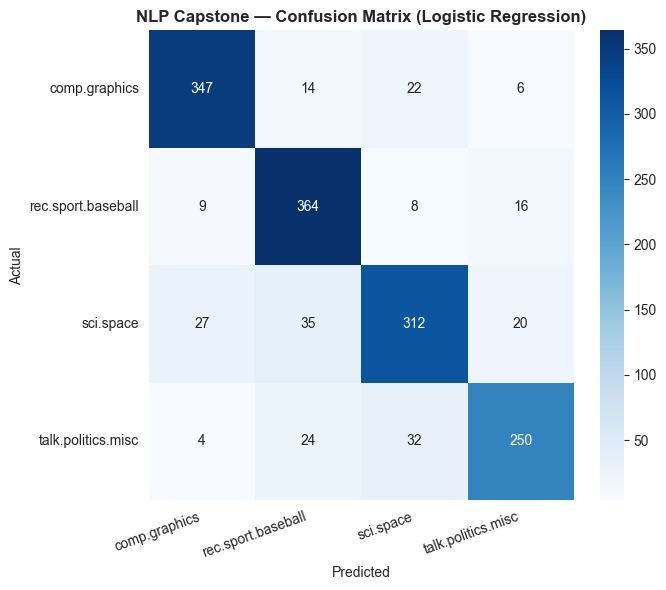

In [68]:
# ── 13e. Confusion matrix on best model ───────────────────────────────────
cm = confusion_matrix(test.target, pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train.target_names, yticklabels=train.target_names)
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.title('NLP Capstone — Confusion Matrix (Logistic Regression)', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()


In [69]:
# ── 13f. Live prediction on raw text ──────────────────────────────────────
samples = [
    'The pitcher threw a no-hitter in the world series final game last night.',
    'NASA announced a new mission to Mars launching next year.',
    'I am rendering 3D animations using a new GPU and ray-tracing engine.',
    'The senator gave a speech criticizing the new tax policy in congress.',
]
sample_clean = [clean(s) for s in samples]
preds = nlp_pipe.predict(sample_clean)
for s, p in zip(samples, preds):
    print(f'[{train.target_names[p]:25s}]  {s[:70]}...')


[rec.sport.baseball       ]  The pitcher threw a no-hitter in the world series final game last nigh...
[sci.space                ]  NASA announced a new mission to Mars launching next year....
[comp.graphics            ]  I am rendering 3D animations using a new GPU and ray-tracing engine....
[talk.politics.misc       ]  The senator gave a speech criticizing the new tax policy in congress....


### Capstone Summary
- TF-IDF + Logistic Regression is a **rock-solid NLP baseline** — beats most heuristics, trains in seconds.
- Modern alternatives:
  - **Word embeddings** (`gensim` / GloVe) — captures semantic similarity
  - **Transformers** (`distilbert` via HuggingFace) — current state of the art
- For production: persist the **whole pipeline** (`tfidf` + `clf` together) so test-time preprocessing is identical.


---
# 14. Summary — Classification Cheat Sheet

### Algorithm choice

| Situation | Try first |
|-----------|-----------|
| Linear, want interpretability | Logistic Regression |
| Text / count features | Multinomial Naive Bayes |
| Small dataset, low-dim | KNN / SVC |
| Tabular, mixed types | **XGBoost / Random Forest** |
| Highly imbalanced | LogReg / XGB + class_weight + threshold tuning |

### Metric choice

| Goal | Metric |
|------|--------|
| Equal cost FP / FN, balanced classes | Accuracy / F1 |
| Minimize false positives | Precision |
| Minimize false negatives (cancer, fraud) | Recall |
| Imbalanced data, threshold-free | ROC-AUC + PR-AUC |
| Probabilities matter (calibration) | Log-loss / Brier score |

### Imbalance toolbox
1. Pick the right metric (never accuracy)
2. `class_weight='balanced'` (LogReg, RF) or `scale_pos_weight` (XGBoost)
3. Oversample minority (manual or SMOTE) — train only
4. Tune the decision threshold

### Pipeline checklist
- [ ] Stratified split
- [ ] Scale numeric features
- [ ] One-hot encode categoricals
- [ ] Wrap everything in a `Pipeline` to prevent leakage
- [ ] Stratified K-Fold CV
- [ ] Hyperparameter tune the winner
- [ ] Evaluate on held-out test set ONCE
- [ ] Save the entire pipeline with `joblib`

### Related notebooks
- Logistic Regression theory: `module4/4.3_classification_models/logistic_regression.ipynb`
- Naive Bayes theory: `module4/4.3_classification_models/naive_bayes.ipynb`
- Random Forest theory: `module4/4.3_classification_models/random_forest.ipynb`
- KNN theory: `module4/4.3_classification_models/knn.ipynb`
- XGBoost notes: `module4/4.3_classification_models/xgboost_notes.ipynb`
- NLP module: `NLP/nlp.ipynb`
- Regression counterpart: `supervised_practical_implementation/regression_model_practical.ipynb`
